# CA Governor Race 2026 — Contributor Industry Classification Review

This notebook walks through four stages:
1. **Campaign data** — preview the raw contributions file
2. **Training data** — preview the labeled org corpus from the NLP repo
3. **Model overview** — how the KNN classifier works end-to-end
4. **Classification results** — confident vs uncertain predictions, manual review samples

In [1]:
import sys, warnings, re
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

# ── Paths ──────────────────────────────────────────────────────────────────────
BASE   = Path("/Users/kateli/Desktop/CalMatters/campaign finance categorization")
RAW    = BASE / "data/governor_race_2026-03-20.csv"
TRAIN  = BASE / "data/OrganizationsFull.tsv"
RESULT = BASE / "data/governor_race_classified.csv"

print("Paths OK:", all(p.exists() for p in [RAW, TRAIN, RESULT]))

Paths OK: True


---
## 1. Campaign Data Preview

In [2]:
raw = pd.read_csv(RAW, dtype=str)
raw["Amount"] = pd.to_numeric(raw["Amount"], errors="coerce")

print(f"Shape:  {raw.shape[0]:,} rows × {raw.shape[1]} columns")
print(f"Columns: {list(raw.columns)}\n")
raw.head(15)

Shape:  89,607 rows × 22 columns
Columns: ['Transaction Type', 'Cycle', 'Election', 'Start Date', 'End Date', 'Amount', 'Recipient Name', 'Recipient Committee', 'Recipient Committee ID', 'Office', 'District', 'Ballot Measure(s)', 'Contributor Name', 'Contributor ID', 'Contributor City', 'Contributor State', 'Contributor Zip Code', 'Contributor Employer', 'Contributor Occupation', 'Candidate Contribution', 'Ballot Measure Contribution', 'Allied Committee']



,Transaction Type,Cycle,Election,Start Date,End Date,Amount,Recipient Name,Recipient Committee,Recipient Committee ID,Office,...,Contributor Name,Contributor ID,Contributor City,Contributor State,Contributor Zip Code,Contributor Employer,Contributor Occupation,Candidate Contribution,Ballot Measure Contribution,Allied Committee
0,Monetary Contribution,2025,0000-00-00,2025-06-02,2025-06-02,100.00,"VILLARAIGOSA, ANTONIO",Antonio Villaraigosa for Governor 2026,1471635,Governor,...,"Kelly, Patrick",NaN,Okoboji,IA,51355,NaN,Not Employed,Y,N,N
1,Monetary Contribution,2025,0000-00-00,2025-03-12,2025-03-12,25000.00,"VILLARAIGOSA, ANTONIO",Antonio Villaraigosa for Governor 2026,1471635,Governor,...,"Khorsandi, Arash",NaN,Los Angeles,CA,90010,Arash Khorsandi,Attorney,Y,N,N
2,Monetary Contribution,2025,0000-00-00,2025-06-25,2025-06-25,258.88,"VILLARAIGOSA, ANTONIO",Antonio Villaraigosa for Governor 2026,1471635,Governor,...,"Kieffer, George",NaN,Los Angeles,CA,90049,"Manatt, Phelps & Phillips, LLC",Attorney,Y,N,N
3,Monetary Contribution,2025,0000-00-00,2025-06-25,2025-06-25,258.87,"VILLARAIGOSA, ANTONIO",Antonio Villaraigosa for Governor 2026,1471635,Governor,...,"Kieffer, Judith",NaN,Los Angeles,CA,90049,NaN,Homemaker,Y,N,N
4,Monetary Contribution,2025,0000-00-00,2025-06-04,2025-06-04,200.00,"VILLARAIGOSA, ANTONIO",Antonio Villaraigosa for Governor 2026,1471635,Governor,...,"Kim, Howard",NaN,Montebello,CA,90640,Via Care Community Health Center,Dentist,Y,N,N
5,Monetary Contribution,2025,0000-00-00,2025-06-18,2025-06-18,259.00,"VILLARAIGOSA, ANTONIO",Antonio Villaraigosa for Governor 2026,1471635,Governor,...,"Klaiber, Matthew",NaN,Las Vegas,NV,89135,Ensign United States Drilling,Manager,Y,N,N
6,Monetary Contribution,2025,0000-00-00,2025-06-14,2025-06-14,200.00,"VILLARAIGOSA, ANTONIO",Antonio Villaraigosa for Governor 2026,1471635,Governor,...,"Kril, Margaret",NaN,Fountain Valley,CA,92708,NaN,Retired,Y,N,N
7,Monetary Contribution,2025,0000-00-00,2025-06-30,2025-06-30,100.00,"VILLARAIGOSA, ANTONIO",Antonio Villaraigosa for Governor 2026,1471635,Governor,...,"Kruszynski, Chris",NaN,Los Angeles,CA,90066,S&S,Architect,Y,N,N
8,Monetary Contribution,2025,0000-00-00,2025-02-24,2025-02-24,500.00,"VILLARAIGOSA, ANTONIO",Antonio Villaraigosa for Governor 2026,1471635,Governor,...,"Lehrer, Miriam M.",NaN,Los Angeles,CA,90027,Studio-MLA,President,Y,N,N
9,Monetary Contribution,2025,0000-00-00,2025-06-23,2025-06-23,10350.25,"VILLARAIGOSA, ANTONIO",Antonio Villaraigosa for Governor 2026,1471635,Governor,...,"Leon, Francisco",NaN,Valencia,CA,91354,California Resources Corporation,Executive,Y,N,N


In [3]:
# Candidate summary
raw["Amount"] = pd.to_numeric(raw["Amount"], errors="coerce")
summary = (
    raw.groupby("Recipient Name")["Amount"]
    .agg(Contributions="count", Total_Raised="sum", Median="median")
    .sort_values("Total_Raised", ascending=False)
)
print("── Candidates in dataset ──")
display(summary)

# Employer / Occupation fill rates
emp_filled  = (raw["Contributor Employer"].notna() & ~raw["Contributor Employer"].isin(["n/a","N/A",""])).mean()
occ_filled  = (raw["Contributor Occupation"].notna() & ~raw["Contributor Occupation"].isin(["n/a","N/A",""])).mean()
print(f"\nEmployer field filled:   {emp_filled:.1%}")
print(f"Occupation field filled: {occ_filled:.1%}")

── Candidates in dataset ──


,Contributions,Total_Raised,Median
Recipient Name,,,
"STEYER, THOMAS F.",97,88513818.72,1000.00
"MAHAN, MATT",430,10831443.75,39200.00
"HILTON, STEVE",17994,6288744.83,75.00
"PORTER, KATIE",48621,5847166.28,25.00
"SWALWELL, ERIC M.",1854,5834473.96,100.00
"BIANCO, CHAD",10416,4066122.32,100.00
"CLOOBECK, STEPHEN J.",80,3990981.00,1000.00
"VILLARAIGOSA, ANTONIO",1008,3614038.02,500.00
"BECERRA, XAVIER",2865,2855151.28,100.00



Employer field filled:   58.7%
Occupation field filled: 97.4%


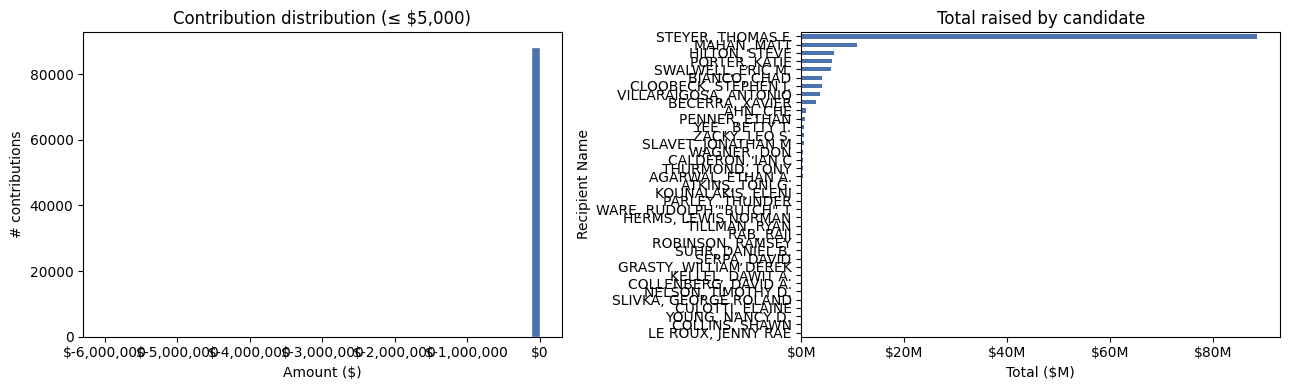

In [4]:
# Contribution size distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

amounts = raw["Amount"].dropna()
axes[0].hist(amounts[amounts > 0], bins=50, color="#4C72B0", edgecolor="white")
axes[0].set_xscale("log")
axes[0].set_title("Contribution distribution (log scale)")
axes[0].set_xlabel("Amount ($, log scale)")
axes[0].set_ylabel("# contributions")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

by_cand = raw.groupby("Recipient Name")["Amount"].sum().sort_values()
by_cand.plot(kind="barh", ax=axes[1], color="#4C72B0")
axes[1].set_title("Total raised by candidate")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M"))
axes[1].set_xlabel("Total ($M)")
axes[1].tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.show()

---
## 2. Training Data Preview

The KNN is trained on **OrganizationsFull.tsv** from [bernicelau430/Label-Organization-Categories-NLP](https://github.com/bernicelau430/Label-Organization-Categories-NLP) — 18,626 California lobbying organizations labeled with a three-level hierarchy (Business → Group → Industry). The repo's 109 Industry labels are crosswalked to our 12 target categories.

In [5]:
train_raw = pd.read_csv(TRAIN, sep="\t", dtype=str, low_memory=False)
print(f"Shape: {train_raw.shape[0]:,} rows × {train_raw.shape[1]} columns")
print(f"Columns: {list(train_raw.columns)}\n")
train_raw.head(8)

Shape: 18,626 rows × 10 columns
Columns: ['Unnamed: 0', 'oid', 'name_org', 'oc_id', 'Business', 'Group', 'Industry', 'name_concept', 'acronym', 'canon_oid']



,Unnamed: 0,oid,name_org,oc_id,Business,Group,Industry,name_concept,acronym,canon_oid
0,0,29,Union Of American Physicians And Dentists,-12160,Health worker unions,Labor,General Trade Unions,Union Of American Physicians And Dentists,NaN,29.0
1,1,37,California Association Of Highway Patrolmen,-1928,Police unions & associations,Labor,Public Sector Unions,California Association Of Highway Patrolmen,NaN,37.0
2,2,39,California Association Of Professional Scientists,-1976,Other unions,Labor,General Trade Unions,California Association Of Professional Scientists,NaN,39.0
3,3,40,California Athletic Trainers Association,-2022,Uncoded,Uncoded,Uncoded,California Athletic Trainers Association,NaN,40.0
4,4,41,Cdf Firefighters,-3318,Fire fighters unions and associations,Labor,Public Sector Unions,Cdf Firefighters,NaN,41.0
5,5,45,Ford Motor Company,-5579,Auto manufacturers,Transportation,Automotive,Ford Motor Company,NaN,45.0
6,6,46,"Waste Management, Inc. & Affiliated Entities",-12573,Waste management,Energy & Natural Resources,Waste Management,Waste Management,NaN,10128.0
7,7,48,Barona Band Of Mission Indians,-1298,Native American tribes & governing units,Government Agencies/Education/Other,Tribal Governments,Barona Band Of Mission Indians,NaN,48.0


In [6]:
# Crosswalk: repo Industry label → our 12 target categories
#
# Changes from initial version:
#   • Beer/Wine/Liquor, Food & Beverage, Food Processing removed from Ag
#     → these labels cover restaurants, distributors & candy companies that
#       are not meaningfully agricultural, and were causing false positives.
REPO_TO_TARGET = {
    # Tech
    "Computer Equipment & Services":          "Tech",
    "Electronics Manufacturing & Services":   "Tech",
    "Telecom Services & Equipment":           "Tech",
    "Telephone Utilities":                    "Tech",
    "Cable TV":                               "Tech",
    "Miscellaneous Communications & Electronics": "Tech",
    # Labor
    "General Trade Unions":                   "Labor",
    "Public Sector Unions":                   "Labor",
    "Transportation Unions":                  "Labor",
    # Oil
    "Oil & Gas":                              "Oil",
    "Miscellaneous Energy":                   "Oil",
    # Utilities
    "Electric Utilities":                     "Utilities",
    "Water Utilities":                        "Utilities",
    "Waste Management":                       "Utilities",
    # Ag — narrowed to genuine farm/ranch/crop labels only
    "Crop Production & Basic Processing":     "Ag",
    "Dairy":                                  "Ag",
    "Livestock":                              "Ag",
    "Poultry & Eggs":                         "Ag",
    "Forestry & Forest Products":             "Ag",
    "Agricultural Services & Products":       "Ag",
    "Miscellaneous Agriculture":              "Ag",
    "Farm Bureau":                            "Ag",
    # Beer/Wine/Liquor  → removed
    # Food & Beverage   → removed
    # Food Processing & Sales → removed
    # Political
    "Candidate Committees":                   "Political",
    "Candidate Contributions":                "Political",
    "Party Committees":                       "Political",
    "Leadership PACs":                        "Political",
    "Joint Candidate Committee":              "Political",
    "Liberal Policy Organization":            "Political",
    "Conservative Policy Organization":       "Political",
    "Christian Conservative":                 "Political",
    # Health Care
    "Health Professionals":                   "Health Care",
    "Hospitals & Nursing Homes":              "Health Care",
    "Pharmaceuticals & Health Products":      "Health Care",
    "Health Services":                        "Health Care",
    "Miscellaneous Health":                   "Health Care",
    "Health & Welfare Policy":                "Health Care",
    # Environment
    "Pro-Environmental Policy":               "Environment",
    "Environmental Services & Equipment":     "Environment",
    "Animal Rights":                          "Environment",
    # Real Estate
    "Real Estate":                            "Real Estate",
    "Home Builders":                          "Real Estate",
    "Construction Services":                  "Real Estate",
    "General Contractors":                    "Real Estate",
    "Special Trade Contractors":              "Real Estate",
    "Building Materials & Equipment":         "Real Estate",
    # Lawyers/Lobbying
    "Lawyers & Lobbyists":                    "Lawyers/Lobbying",
    "Accountants":                            "Lawyers/Lobbying",
}

train_raw["Target_Category"] = train_raw["Industry"].map(REPO_TO_TARGET)
mapped   = train_raw.dropna(subset=["Target_Category"])
unmapped = train_raw[
    train_raw["Target_Category"].isna() & (train_raw["Industry"] != "Uncoded")
]

print(f"Total orgs:           {len(train_raw):,}")
print(f"Mapped to 12 cats:    {len(mapped):,}")
print(f"Uncoded (excluded):   {(train_raw['Industry']=='Uncoded').sum():,}")
print(f"Other (not in scope): {len(unmapped):,}  (Insurance, Automotive, Gambling, etc.)")
print(f"\nTraining corpus used by KNN: {len(mapped):,} orgs across "
      f"{mapped['Target_Category'].nunique()} categories")


Total orgs:           18,626
Mapped to 12 cats:    5,868
Uncoded (excluded):   10,193
Other (not in scope): 2,565  (Insurance, Automotive, Gambling, etc.)

Training corpus used by KNN: 5,868 orgs across 10 categories


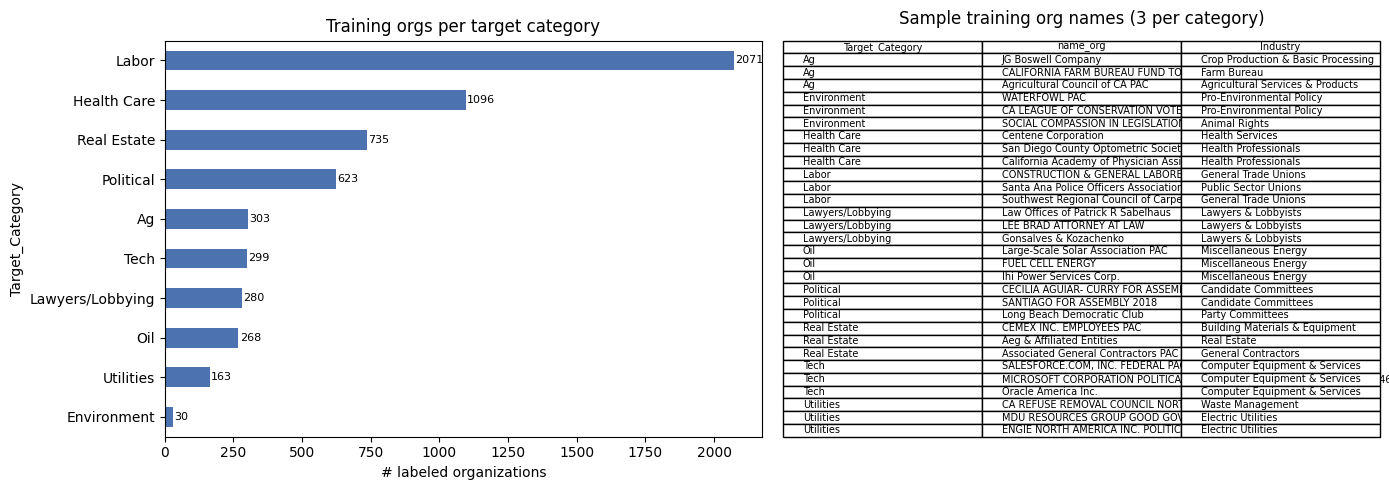

In [7]:
# Training data composition
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: orgs per target category
cat_counts = mapped["Target_Category"].value_counts().sort_values()
cat_counts.plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_title("Training orgs per target category")
axes[0].set_xlabel("# labeled organizations")
for i, v in enumerate(cat_counts):
    axes[0].text(v + 5, i, str(v), va="center", fontsize=8)

# Right: sample names per category (3 per category)
sample_rows = (
    mapped.groupby("Target_Category")
    .apply(lambda g: g.sample(min(3, len(g)), random_state=42))
    .reset_index(drop=True)[["Target_Category", "name_org", "Industry"]]
    .sort_values("Target_Category")
)
axes[1].axis("off")
tbl = axes[1].table(
    cellText=sample_rows.values,
    colLabels=sample_rows.columns,
    cellLoc="left",
    loc="center",
    bbox=[0, 0, 1, 1],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(7)
axes[1].set_title("Sample training org names (3 per category)", pad=12)

plt.tight_layout()
plt.show()

---
## 3. Model Overview

### How it works

```
Contributor Employer  ──┐
                        ├─► preprocess() ──► keyword match? ──► label (high confidence)
Contributor Name ───────┘                         │
                                                  ▼ no match
                                        TF-IDF vectorize
                                        (word n-grams + char n-grams)
                                                  │
                                        cosine similarity
                                        vs 6,191 training orgs
                                                  │
                                        k=3 nearest neighbors
                                        weighted vote  ──────────► label + confidence
                                                  │
                                        conf < 0.40?  ──► knn_low_conf
```

**Preprocessing** strips entity suffixes (Inc, LLC, Corp), expands abbreviations (Mfg→manufacturing, Svcs→services), and removes punctuation so `"Manatt, Phelps & Phillips, LLP"` becomes `"manatt phelps phillips"`.

**Dual TF-IDF** captures both whole-word patterns (`"medical center"`, `"law firm"`) via word n-grams and subword patterns (`"pharma"` inside `"pharmaceutical"`) via character n-grams.

**Keyword pre-pass** fires first for categories absent from the training data (Crypto/AI, Ridesharing) and for clear signals like `"for governor"` → Political or `"union"` → Labor.

**Confidence** = winning category's share of total similarity-weighted vote across k neighbors.

---
## 3b. Data Processing Changes

This section documents decisions made after auditing classifier output.
Each change is reproducible by re-running `classify_contributors.py`.


In [8]:
# Summary of changes made to the classification pipeline after initial audit
changes = [
    {
        "area": "Crosswalk — Ag category",
        "change": "Removed Beer/Wine/Liquor, Food & Beverage, Food Processing & Sales",
        "reason": "These repo labels cover restaurants, distributors and candy companies. "
                  "Including them inflated Ag from ~1,600 to ~4,800 rows and caused "
                  "McDonald's, Harbor Freight Tools and Sanders Candy to appear as Ag.",
        "effect": "Ag: 4,852 → 1,621 rows",
    },
    {
        "area": "Keyword matching — regex",
        "change": "Switched from substring match (kw in text) to word-boundary regex (\\bkw\\b)",
        "reason": "'farm' was matching inside 'State Farm', 'ranch' inside 'Branch Investment Group', "
                  "etc. Word boundaries require the keyword to be a standalone token.",
        "effect": "Eliminated ~15 false-positive keyword matches per category",
    },
    {
        "area": "Keyword blocklist",
        "change": "Added KEYWORD_BLOCKLIST = ['state farm', 'farm credit']",
        "reason": "Even with word-boundary matching, 'State Farm' (insurance) contains 'farm' "
                  "as a genuine standalone word. The blocklist short-circuits before any keyword "
                  "check fires for known false-positive org names.",
        "effect": "State Farm insurance agents now fall through to KNN rather than keyword match. "
                  "Residual: KNN still votes Ag because no Insurance category exists in taxonomy.",
    },
]

import pandas as pd
df_changes = pd.DataFrame(changes)
display(df_changes.style.set_properties(**{"text-align": "left", "white-space": "pre-wrap"})
        .set_table_styles([{"selector": "th", "props": [("text-align", "left")]}]))


,area,change,reason,effect
0,Crosswalk — Ag category,"Removed Beer/Wine/Liquor, Food & Beverage, Food Processing & Sales","These repo labels cover restaurants, distributors and candy companies. Including them inflated Ag from ~1,600 to ~4,800 rows and caused McDonald's, Harbor Freight Tools and Sanders Candy to appear as Ag.","Ag: 4,852 → 1,621 rows"
1,Keyword matching — regex,Switched from substring match (kw in text) to word-boundary regex (\bkw\b),"'farm' was matching inside 'State Farm', 'ranch' inside 'Branch Investment Group', etc. Word boundaries require the keyword to be a standalone token.",Eliminated ~15 false-positive keyword matches per category
2,Keyword blocklist,"Added KEYWORD_BLOCKLIST = ['state farm', 'farm credit']","Even with word-boundary matching, 'State Farm' (insurance) contains 'farm' as a genuine standalone word. The blocklist short-circuits before any keyword check fires for known false-positive org names.",State Farm insurance agents now fall through to KNN rather than keyword match. Residual: KNN still votes Ag because no Insurance category exists in taxonomy.


In [9]:
# Live demo: show preprocessing + nearest neighbors for a few example org names
import importlib.util, scipy.sparse as sp
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

spec = importlib.util.spec_from_file_location(
    "clf", BASE / "code/classify_contributors.py"
)
clf_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(clf_mod)

print("Building KNN model from training data …")
word_vec, char_vec, X_train, train_labels = clf_mod.build_knn_model()
print("Done.\n")

DEMO_ORGS = [
    "Kaiser Permanente",
    "Latham and Watkins LLP",
    "SEIU United Healthcare Workers West",
    "Chevron Corporation",
    "Pacific Gas and Electric",
    "Coinbase Global Inc",
    "Lyft Inc",
    "KB Home",
]

print(f"{'Org name':<42}  {'Preprocessed':<35}  {'Predicted':<18}  Conf")
print("-" * 110)
for name in DEMO_ORGS:
    proc = clf_mod.preprocess(name)
    kw   = clf_mod.keyword_classify(proc) or clf_mod.keyword_classify(name.lower())
    if kw:
        pred, conf, method = kw, 0.90, "keyword"
    else:
        pred, conf = clf_mod.knn_predict(proc, word_vec, char_vec, X_train, train_labels)
        method = "knn"
    print(f"  {name:<40}  {proc:<35}  {pred:<18}  {conf:.2f}  [{method}]")

Building KNN model from training data …
  Repo training orgs after crosswalk: 5,868 (from 10 categories)
  Supplemental seeds added for: {'Crypto/AI', 'Ridesharing'}
  Total training examples: 5,902


Done.

Org name                                    Preprocessed                         Predicted           Conf
--------------------------------------------------------------------------------------------------------------
  Kaiser Permanente                         kaiser permanente                    Health Care         1.00  [knn]
  Latham and Watkins LLP                    latham and watkins liability partnership  Lawyers/Lobbying    0.90  [keyword]
  SEIU United Healthcare Workers West       seiu united healthcare workers west  Labor               0.90  [keyword]
  Chevron Corporation                       chevron                              Oil                 0.90  [keyword]
  Pacific Gas and Electric                  pacific gas and electric             Utilities           0.77  [knn]
  Coinbase Global Inc                       coinbase global                      Crypto/AI           0.90  [keyword]
  Lyft Inc                                  lyft                             

In [10]:
# Show the actual nearest neighbors for one example
def show_neighbors(org_name, k=5):
    proc  = clf_mod.preprocess(org_name)
    q_w   = word_vec.transform([proc])
    q_c   = char_vec.transform([proc])
    q     = sp.hstack([q_w, q_c])
    sims  = cosine_similarity(q, X_train)[0]
    top_idx = sims.argsort()[::-1][:k]

    print(f"\nNearest neighbors for: \"{org_name}\"  (preprocessed: \"{proc}\")")
    print(f"  {'Rank':<5}  {'Similarity':>10}  {'Label':<20}  Training org name")
    print("  " + "-"*75)
    for rank, idx in enumerate(top_idx, 1):
        label    = train_labels[idx]
        org_text = mapped.iloc[idx]["name_org"] if idx < len(mapped) else "(seed)"
        print(f"  {rank:<5}  {sims[idx]:>10.4f}  {label:<20}  {org_text}")

show_neighbors("Community Health Alliance")
show_neighbors("Golden State Oil Producers")


Nearest neighbors for: "Community Health Alliance"  (preprocessed: "community health alliance")
  Rank   Similarity  Label                 Training org name
  ---------------------------------------------------------------------------
  1          0.4851  Health Care           NOMI HEALTH, INC.
  2          0.4581  Health Care           Compass Health, Inc.
  3          0.4503  Health Care           Magellan Health
  4          0.3973  Health Care           ALLHEALTH
  5          0.3392  Health Care           CENTENE MANAGEMENT COMPANY, LLC AND ITS AFFILIATE HEALTH NET COMMUNITY SOLUTIONS, INC.

Nearest neighbors for: "Golden State Oil Producers"  (preprocessed: "golden state oil producers")
  Rank   Similarity  Label                 Training org name
  ---------------------------------------------------------------------------
  1          0.5816  Ag                    Golden State Dairy
  2          0.5291  Utilities             Golden State Water Company
  3          0.5125  Labor 

---
## 4. Classification Results on Campaign Data

In [11]:
res = pd.read_csv(RESULT, dtype=str, low_memory=False)
res["Amount"]                   = pd.to_numeric(res["Amount"],                   errors="coerce")
res["Classification_Confidence"] = pd.to_numeric(res["Classification_Confidence"], errors="coerce")

print(f"Classified rows: {len(res):,}")
print(f"Categories used: {sorted(res['Industry_Category'].dropna().unique())}\n")

# Category distribution (row count + total dollars)
cat_stats = (
    res.groupby("Industry_Category")
    .agg(Rows=("Industry_Category", "count"), Total_Dollars=("Amount", "sum"))
    .sort_values("Rows", ascending=False)
    .reset_index()
)
cat_stats["Pct_Rows"]    = (cat_stats["Rows"]          / len(res)              * 100).round(1)
cat_stats["Pct_Dollars"] = (cat_stats["Total_Dollars"]  / res["Amount"].sum()  * 100).round(1)
display(cat_stats.style.format({"Total_Dollars": "${:,.0f}", "Pct_Rows": "{:.1f}%", "Pct_Dollars": "{:.1f}%"}))

Classified rows: 89,607
Categories used: ['Ag', 'Crypto/AI', 'Environment', 'Health Care', 'Labor', 'Lawyers/Lobbying', 'Not Employed / Retired', 'Oil', 'Political', 'Real Estate', 'Ridesharing', 'Tech', 'Unknown', 'Utilities']



,Industry_Category,Rows,Total_Dollars,Pct_Rows,Pct_Dollars
0,Not Employed / Retired,57435,"$9,432,777",64.1%,6.9%
1,Real Estate,7538,"$9,080,632",8.4%,6.6%
2,Health Care,5418,"$8,320,388",6.0%,6.1%
3,Labor,4362,"$6,746,301",4.9%,4.9%
4,Lawyers/Lobbying,3637,"$4,586,796",4.1%,3.3%
5,Tech,3100,"$2,403,119",3.5%,1.8%
6,Political,2998,"$90,263,845",3.3%,65.9%
7,Ag,1621,"$1,927,703",1.8%,1.4%
8,Oil,1319,"$1,553,311",1.5%,1.1%
9,Utilities,995,"$813,478",1.1%,0.6%


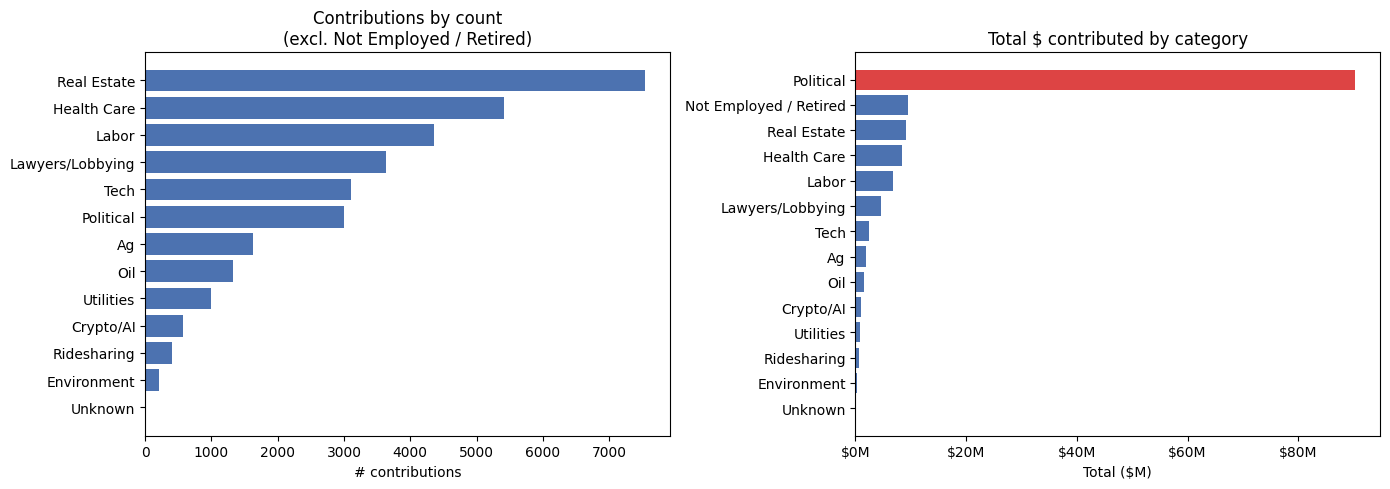

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: rows per category (excluding Not Employed)
active = cat_stats[cat_stats["Industry_Category"] != "Not Employed / Retired"].sort_values("Rows")
axes[0].barh(active["Industry_Category"], active["Rows"], color="#4C72B0")
axes[0].set_title("Contributions by count\n(excl. Not Employed / Retired)")
axes[0].set_xlabel("# contributions")

# Right: dollars per category
dollar_order = cat_stats.sort_values("Total_Dollars")
colors = ["#dd4444" if c == "Political" else "#4C72B0" for c in dollar_order["Industry_Category"]]
axes[1].barh(dollar_order["Industry_Category"], dollar_order["Total_Dollars"] / 1e6, color=colors)
axes[1].set_title("Total $ contributed by category")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}M"))
axes[1].set_xlabel("Total ($M)")

plt.tight_layout()
plt.show()

---
## 5. Confidence Analysis & Manual Review

The classifier assigns a **confidence score** (0–1) to every non-retired row:
- **`special_case`** — exact match on "retired", "not employed", etc. → always 1.0
- **`keyword`** → fixed at 0.90
- **`knn`** → similarity-weighted vote ≥ 0.40 threshold
- **`occupation_hint`** → fixed at 0.60 (fallback from job title)
- **`knn_low_conf`** → best KNN guess below threshold — most likely to be wrong

Classification method breakdown:
  special_case           57,407  (64.1%)
  knn                    23,102  (25.8%)
  knn_low_conf            4,836  (5.4%)
  keyword                 3,652  (4.1%)
  occupation_hint           610  (0.7%)

Of the 32,200 rows the model actively classified:
  15.0% have confidence < 0.40 (very uncertain)


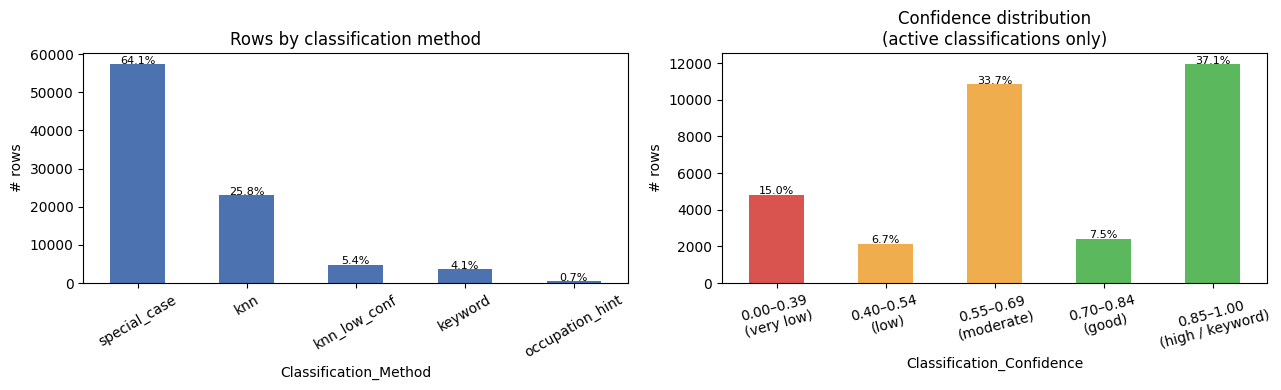

In [13]:
# Classification method breakdown + confidence distribution
method_counts = res["Classification_Method"].value_counts()
total = len(res)
print("Classification method breakdown:")
for method, n in method_counts.items():
    print(f"  {method:<20}  {n:>7,}  ({n/total*100:.1f}%)")

# Focus on rows the model had to actually decide (not special-case)
active_rows = res[res["Classification_Method"] != "special_case"].copy()
n_active = len(active_rows)

bins   = [0.0, 0.40, 0.55, 0.70, 0.85, 1.01]
labels = ["0.00–0.39\n(very low)", "0.40–0.54\n(low)", "0.55–0.69\n(moderate)",
          "0.70–0.84\n(good)", "0.85–1.00\n(high / keyword)"]
cuts   = pd.cut(active_rows["Classification_Confidence"], bins=bins, labels=labels, right=False)
conf_dist = cuts.value_counts().reindex(labels)

low_conf_pct = (active_rows["Classification_Confidence"] < 0.40).sum() / n_active
print(f"\nOf the {n_active:,} rows the model actively classified:")
print(f"  {low_conf_pct:.1%} have confidence < 0.40 (very uncertain)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

method_counts.plot(kind="bar", ax=axes[0], color="#4C72B0", rot=30)
axes[0].set_title("Rows by classification method")
axes[0].set_ylabel("# rows")
for i, v in enumerate(method_counts):
    axes[0].text(i, v + 50, f"{v/total:.1%}", ha="center", fontsize=8)

conf_dist.plot(kind="bar", ax=axes[1], color=["#d9534f","#f0ad4e","#f0ad4e","#5cb85c","#5cb85c"], rot=15)
axes[1].set_title("Confidence distribution\n(active classifications only)")
axes[1].set_ylabel("# rows")
for i, v in enumerate(conf_dist):
    axes[1].text(i, v + 30, f"{v/n_active:.1%}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

### 5a. High-confidence sample — sanity check that confident predictions look right

In [ ]:
REVIEW_COLS = ["Contributor Name", "Org_Text_Used", "Contributor Occupation",
               "Industry_Category", "Classification_Confidence", "Classification_Method", "Amount"]

# High confidence: keyword matches and KNN ≥ 0.80, excluding special_case
high_conf = active_rows[active_rows["Classification_Confidence"] >= 0.80].copy()

# Sample 5 per category for variety
sample_high = (
    high_conf.groupby("Industry_Category", group_keys=False)
    .apply(lambda g: g.sample(min(5, len(g)), random_state=1))
    .sort_values(["Industry_Category", "Classification_Confidence"], ascending=[True, False])
    .reset_index(drop=True)
)

High-confidence rows (≥ 0.80): 12,286  (38.2% of active classifications)



,Contributor Name,Org_Text_Used,Contributor Occupation,Industry_Category,Classification_Confidence,Classification_Method,Amount
0,"Heringer, Jr., Lester",M & T Farms,Farmer,Ag,1.00,knn,$100.00
1,"Smith, Myra",State Farm,Underwriter,Ag,1.00,knn,$20.00
2,"De Jager, Renae",Vista Verde Dairy,Dairyfarmer,Ag,0.90,keyword,"$2,500.00"
3,"King, David E.",Fairbanks Ranch Association,Security,Ag,0.90,keyword,$10.00
4,"Ghiringhelli Nelson, Helen",Heibel Ranch Vineyards,Winery Owner,Ag,0.90,keyword,$50.00
5,"Vella, Malia",Amira Learning,Vice President,Crypto/AI,0.90,knn,"$1,000.00"
6,"Swank, Danielle",Fomoro Artificial Intelligence,Founder,Crypto/AI,0.90,keyword,$25.00
7,"Californians for Responsible Artificial Intelligence, Sponsored by Encode AI Corporation","Californians for Responsible Artificial Intelligence, Sponsored by Encode AI Corporation",nan,Crypto/AI,0.90,keyword,"$10,000.00"
8,"Morales, Bob",Lifelong Learning Administration Corporation,Chief External Affairs Officer,Crypto/AI,0.89,knn,$100.00
9,"Bergman, Ernie","AI Insight, Inc.",Director,Crypto/AI,0.83,knn,$50.00


### 5b. Low-confidence sample — cases most worth manually reviewing

These are `knn_low_conf` rows (confidence < 0.40) where the model had no keyword match and the nearest neighbors were weakly similar. The predicted label is a best guess — it may well be wrong or the contributor simply doesn't fit any of the 12 categories.

In [ ]:
low_conf = active_rows[active_rows["Classification_Method"] == "knn_low_conf"].copy()

# Deduplicate by org text so we aren't showing the same employer 20 times
low_conf_dedup = (
    low_conf.sort_values("Classification_Confidence")
    .drop_duplicates(subset=["Org_Text_Used"])
)

# Sample 6 per category
sample_low = (
    low_conf_dedup.groupby("Industry_Category", group_keys=False)
    .apply(lambda g: g.nsmallest(6, "Classification_Confidence"))
    .sort_values(["Industry_Category", "Classification_Confidence"])
    .reset_index(drop=True)
)

Low-confidence rows (knn_low_conf): 4,836  (15.0% of active classifications)
Unique org names in that group:     1,906



,Contributor Name,Org_Text_Used,Contributor Occupation,Industry_Category,Classification_Confidence,Classification_Method,Amount
0,"Morgan, Van",Daybreak,Founder,Ag,0.33,knn_low_conf,"$3,000.00"
1,"McFarland, David",Maco Equipement,Owner,Ag,0.34,knn_low_conf,"$7,933.85"
2,"Harrigan, Patricia",Crohn's & Colitis Foundation,Field Operations,Ag,0.34,knn_low_conf,$100.00
3,"Msrtin, Dawn",Ceres,EVP,Ag,0.34,knn_low_conf,$10.00
4,"Ruthroff, Donald",Design Story Spaces,Architect,Ag,0.34,knn_low_conf,$100.00
5,"Jenkins, Trisha","Jenkins, Trisha",Stay at home mom,Ag,0.34,knn_low_conf,$105.00
6,"Cattivera, Sara",O'BRIEN GARRETT,ACCOUNT DIRECTOR,Crypto/AI,0.33,knn_low_conf,$100.00
7,"Chunn, Cliff","Cliff Chunn, Entrepreneur",Entrepreneur,Crypto/AI,0.34,knn_low_conf,$500.00
8,"Halverson, Eric",Ocv,CEO,Crypto/AI,0.34,knn_low_conf,$215.00
9,"Handler, Bruce",Core Coaching Advantage,Career Coach,Crypto/AI,0.34,knn_low_conf,$250.00


### 5c. Low-confidence breakdown by category

Which categories attract the most uncertain predictions? A high share of low-confidence rows in a category suggests the KNN is pattern-matching on weak signal — either the category is underrepresented in training data, or many real contributors simply don't fit any of the 12 categories cleanly.

,Industry_Category,Total_Active,Low_Conf,Median_Conf,Mean_Conf,Pct_Low_Conf
12,Unknown,1,1,0.00,0.00,100.0%
2,Environment,210,96,0.45,0.53,45.7%
1,Crypto/AI,563,213,0.42,0.53,37.8%
10,Ridesharing,410,133,0.43,0.52,32.4%
5,Lawyers/Lobbying,3637,863,0.67,0.65,23.7%
7,Oil,1319,303,0.66,0.67,23.0%
13,Utilities,995,199,0.65,0.69,20.0%
0,Ag,1621,274,0.67,0.70,16.9%
9,Real Estate,7538,1254,0.68,0.72,16.6%
8,Political,2998,488,0.69,0.72,16.3%


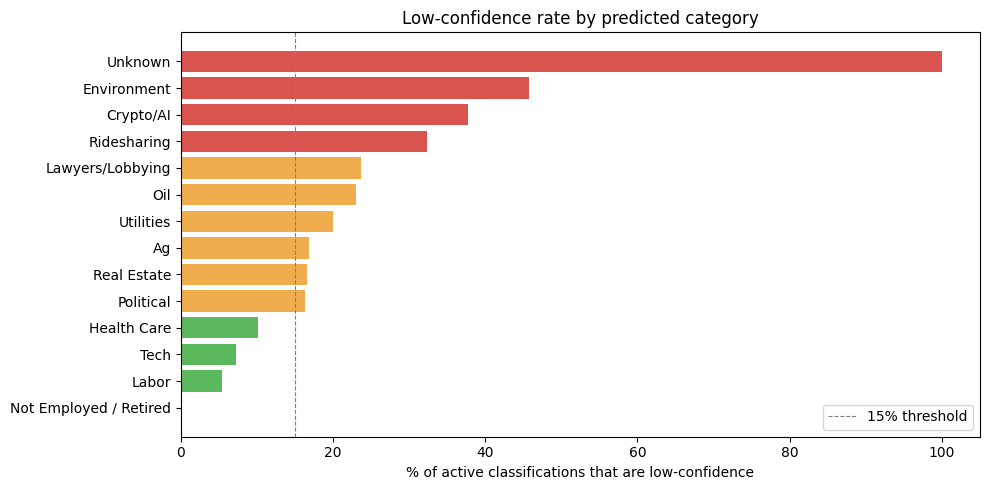

In [16]:
conf_by_cat = (
    active_rows.groupby("Industry_Category")
    .agg(
        Total_Active=("Classification_Confidence", "count"),
        Low_Conf=("Classification_Method", lambda x: (x == "knn_low_conf").sum()),
        Median_Conf=("Classification_Confidence", "median"),
        Mean_Conf=("Classification_Confidence", "mean"),
    )
    .reset_index()
)
conf_by_cat["Pct_Low_Conf"] = (conf_by_cat["Low_Conf"] / conf_by_cat["Total_Active"] * 100).round(1)
conf_by_cat = conf_by_cat.sort_values("Pct_Low_Conf", ascending=False)

display(
    conf_by_cat.style
    .format({"Median_Conf": "{:.2f}", "Mean_Conf": "{:.2f}", "Pct_Low_Conf": "{:.1f}%"})
    .bar(subset=["Pct_Low_Conf"], color="#d9534f", vmin=0, vmax=100)
    .bar(subset=["Median_Conf"],  color="#5cb85c", vmin=0, vmax=1)
)

fig, ax = plt.subplots(figsize=(10, 5))
order = conf_by_cat.sort_values("Pct_Low_Conf")
bars = ax.barh(order["Industry_Category"], order["Pct_Low_Conf"],
               color=["#d9534f" if v > 30 else "#f0ad4e" if v > 15 else "#5cb85c"
                      for v in order["Pct_Low_Conf"]])
ax.set_xlabel("% of active classifications that are low-confidence")
ax.set_title("Low-confidence rate by predicted category")
ax.axvline(15, color="gray", linestyle="--", linewidth=0.8, label="15% threshold")
ax.legend()
plt.tight_layout()
plt.show()

### 5d. Interactive spot-check — filter by category and confidence tier

Use the cell below to slice any category + confidence range and print a readable review table.

In [ ]:
# ── ADJUST THESE TO EXPLORE ───────────────────────────────────────────────────
CATEGORY      = "Ag"          # one of the 12 categories, or None for all
CONF_MIN      = 0.0           # minimum confidence (0.0–1.0)
CONF_MAX      = 0.45          # maximum confidence (0.0–1.0)
N_ROWS        = 30            # how many rows to display
DEDUP_BY_ORG  = True          # show each unique employer only once
# ─────────────────────────────────────────────────────────────────────────────

subset = active_rows.copy()
if CATEGORY:
    subset = subset[subset["Industry_Category"] == CATEGORY]
subset = subset[
    (subset["Classification_Confidence"] >= CONF_MIN) &
    (subset["Classification_Confidence"] <= CONF_MAX)
]
if DEDUP_BY_ORG:
    subset = subset.drop_duplicates(subset=["Org_Text_Used"])

subset = subset.sort_values("Classification_Confidence").head(N_ROWS).reset_index(drop=True)

Category: Ag  |  Confidence: 0.0–0.45  |  Showing 30 rows (dedup=True)



,Contributor Name,Org_Text_Used,Contributor Occupation,Industry_Category,Classification_Confidence,Classification_Method,Amount
0,"Morgan, Van",Daybreak,Founder,Ag,0.33,knn_low_conf,"$3,000.00"
1,"Harrigan, Patricia",Crohn's & Colitis Foundation,Field Operations,Ag,0.34,knn_low_conf,$100.00
2,"McFarland, David",Maco Equipement,Owner,Ag,0.34,knn_low_conf,"$7,933.85"
3,"Msrtin, Dawn",Ceres,EVP,Ag,0.34,knn_low_conf,$10.00
4,"Ruthroff, Donald",Design Story Spaces,Architect,Ag,0.34,knn_low_conf,$50.00
5,"Jenkins, Trisha","Jenkins, Trisha",Stay at home mom,Ag,0.34,knn_low_conf,$105.00
6,"Gross, Danielle",Rso,Senior clinical therapist,Ag,0.34,knn_low_conf,$61.00
7,"Garlathy, Sydian","Garlathy, Sydian",nan,Ag,0.34,knn_low_conf,$111.00
8,American Sportfishing Associatin PAC,American Sportfishing Associatin PAC,nan,Ag,0.34,knn_low_conf,$999.00
9,"Koshi, Tom",Dhs/Ice/Ero,Detention & Deportation Officer,Ag,0.34,knn_low_conf,$259.92


---
## 6. Visualizations

### Top-10 candidates by total contributions — donation breakdown by industry category

Each pie chart shows the share of total dollars received by that candidate, split by
the contributor's classified industry. "Not Employed / Retired" is shown separately
so individual small-donor giving is visible alongside organised-sector money.


In [18]:
# Consistent color map across all charts
CATEGORY_COLORS = {
    "Political":              "#e63946",
    "Labor":                  "#f4a261",
    "Real Estate":            "#2a9d8f",
    "Health Care":            "#457b9d",
    "Lawyers/Lobbying":       "#8338ec",
    "Tech":                   "#3a86ff",
    "Ag":                     "#80b918",
    "Oil":                    "#6d4c41",
    "Crypto/AI":              "#ff006e",
    "Ridesharing":            "#fb5607",
    "Utilities":              "#ffbe0b",
    "Environment":            "#06d6a0",
    "Not Employed / Retired": "#adb5bd",
    "Unknown":                "#dee2e6",
}

# Load results (re-load to be safe after any re-runs)
res = pd.read_csv(RESULT, dtype=str, low_memory=False)
res["Amount"] = pd.to_numeric(res["Amount"], errors="coerce")
print(f"Loaded {len(res):,} classified rows.")


Loaded 89,607 classified rows.


In [19]:
# Identify top 10 candidates by total contributions
top10_candidates = (
    res.groupby("Recipient Name")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)
print("Top 10 candidates:")
for i, c in enumerate(top10_candidates, 1):
    total = res[res["Recipient Name"] == c]["Amount"].sum()
    print(f"  {i:>2}. {c:<55}  ${total:>15,.0f}")


Top 10 candidates:
   1. STEYER, THOMAS F.                                        $     88,513,819
   2. MAHAN, MATT                                              $     10,831,444
   3. HILTON, STEVE                                            $      6,288,745
   4. PORTER, KATIE                                            $      5,847,166
   5. SWALWELL, ERIC M.                                        $      5,834,474
   6. BIANCO, CHAD                                             $      4,066,122
   7. CLOOBECK, STEPHEN J.                                     $      3,990,981
   8. VILLARAIGOSA, ANTONIO                                    $      3,614,038
   9. BECERRA, XAVIER                                          $      2,855,151
  10. AHN, CHE                                                 $        838,998


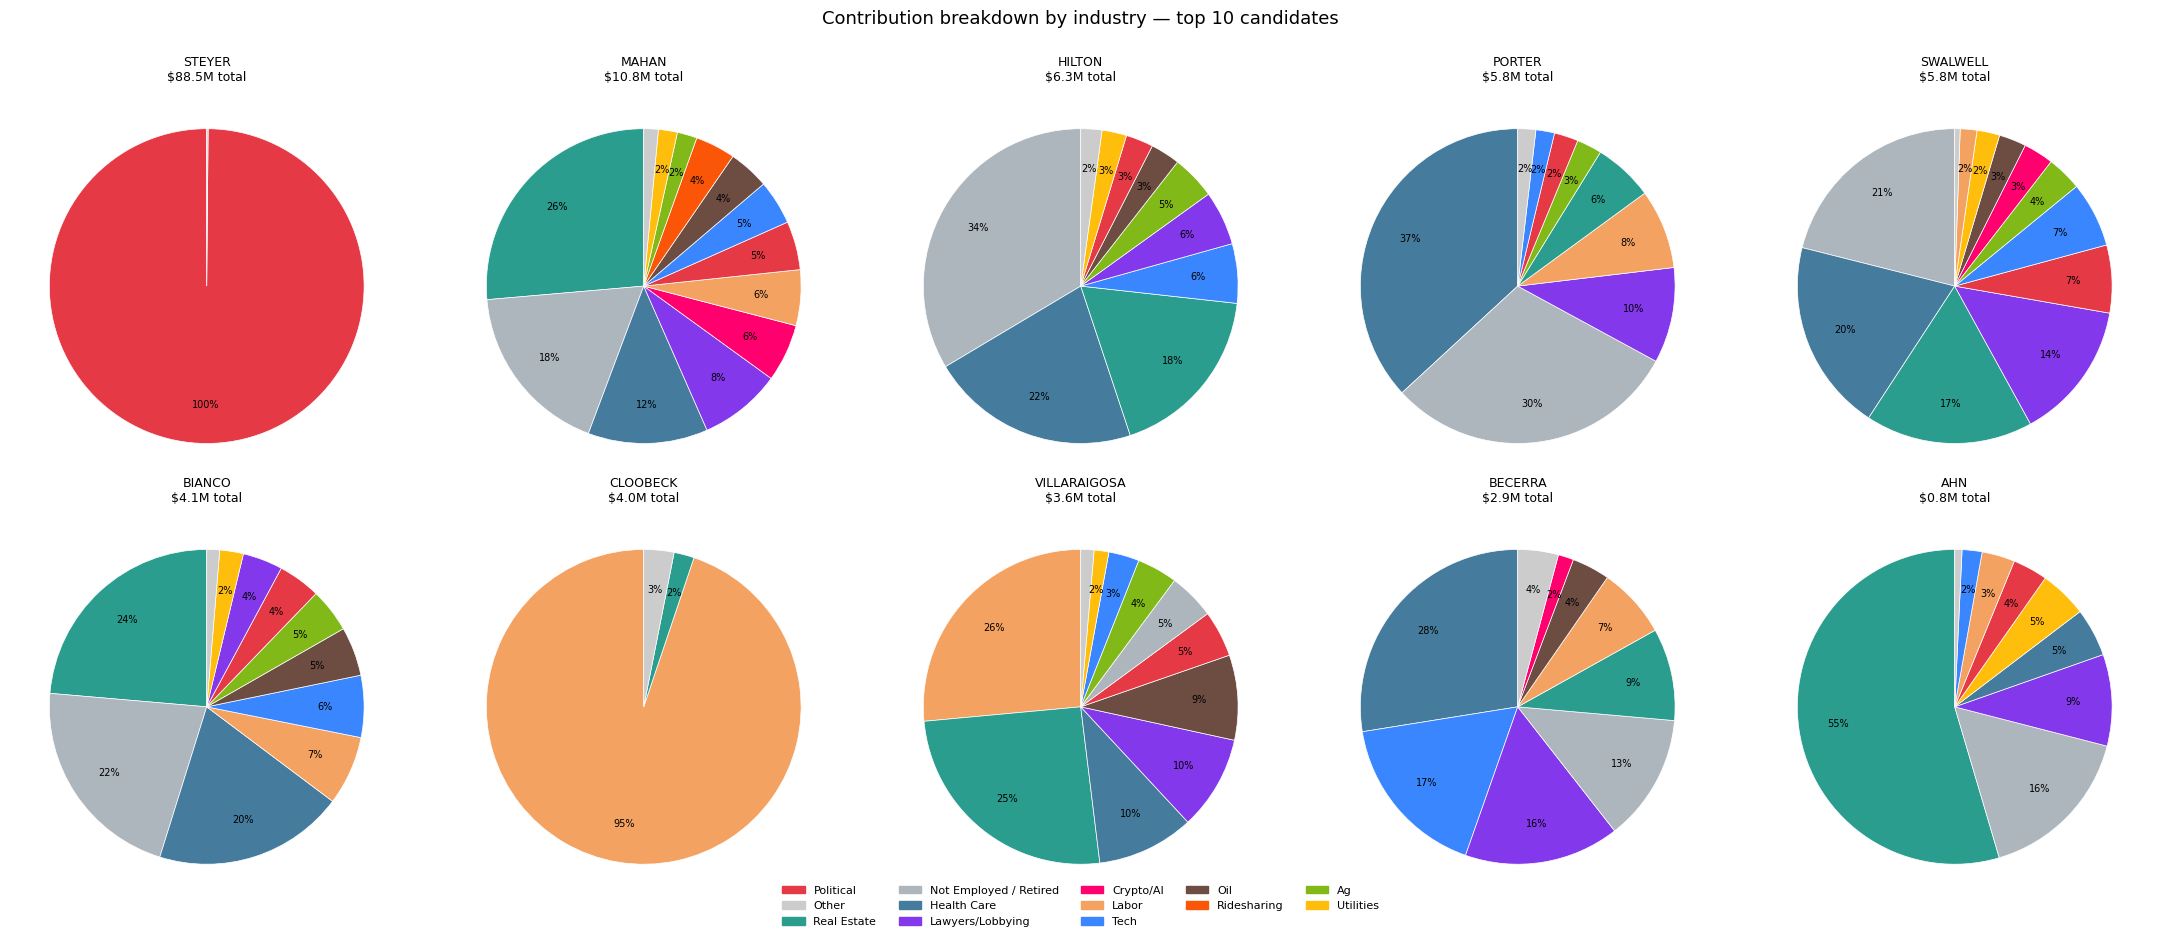

In [20]:
def pie_for_candidate(ax, candidate, res, color_map, min_pct=1.5):
    """
    Draw a pie chart on `ax` for one candidate.
    Slices below min_pct% are merged into 'Other'.
    """
    sub = (
        res[res["Recipient Name"] == candidate]
        .groupby("Industry_Category")["Amount"]
        .sum()
        .sort_values(ascending=False)
    )
    total = sub.sum()

    # Merge tiny slices
    main  = sub[sub / total * 100 >= min_pct]
    other = sub[sub / total * 100 <  min_pct].sum()
    if other > 0:
        main["Other"] = other

    colors = [color_map.get(cat, "#cccccc") for cat in main.index]

    wedges, texts, autotexts = ax.pie(
        main.values,
        labels=None,
        colors=colors,
        autopct=lambda p: f"{p:.0f}%" if p >= min_pct else "",
        startangle=90,
        wedgeprops={"linewidth": 0.5, "edgecolor": "white"},
        pctdistance=0.75,
    )
    for at in autotexts:
        at.set_fontsize(7)

    # Short candidate label (remove party suffixes for readability)
    short = candidate.split(",")[0] if "," in candidate else candidate
    ax.set_title(f"{short}\n${total/1e6:.1f}M total", fontsize=9, pad=6)
    return main.index.tolist(), colors


# ── Build 2-row × 5-col grid ─────────────────────────────────────────────────
ncols, nrows = 5, 2
fig, axes = plt.subplots(nrows, ncols, figsize=(22, 9))
axes_flat  = axes.flatten()

legend_handles = {}
for ax, candidate in zip(axes_flat, top10_candidates):
    cats, cols = pie_for_candidate(ax, candidate, res, CATEGORY_COLORS)
    for cat, col in zip(cats, cols):
        if cat not in legend_handles:
            legend_handles[cat] = col

# Hide any unused subplots
for ax in axes_flat[len(top10_candidates):]:
    ax.set_visible(False)

# Shared legend below the charts
import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=col, label=cat)
           for cat, col in legend_handles.items()]
fig.legend(handles=patches, loc="lower center", ncol=5,
           fontsize=8, frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.suptitle("Contribution breakdown by industry — top 10 candidates",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


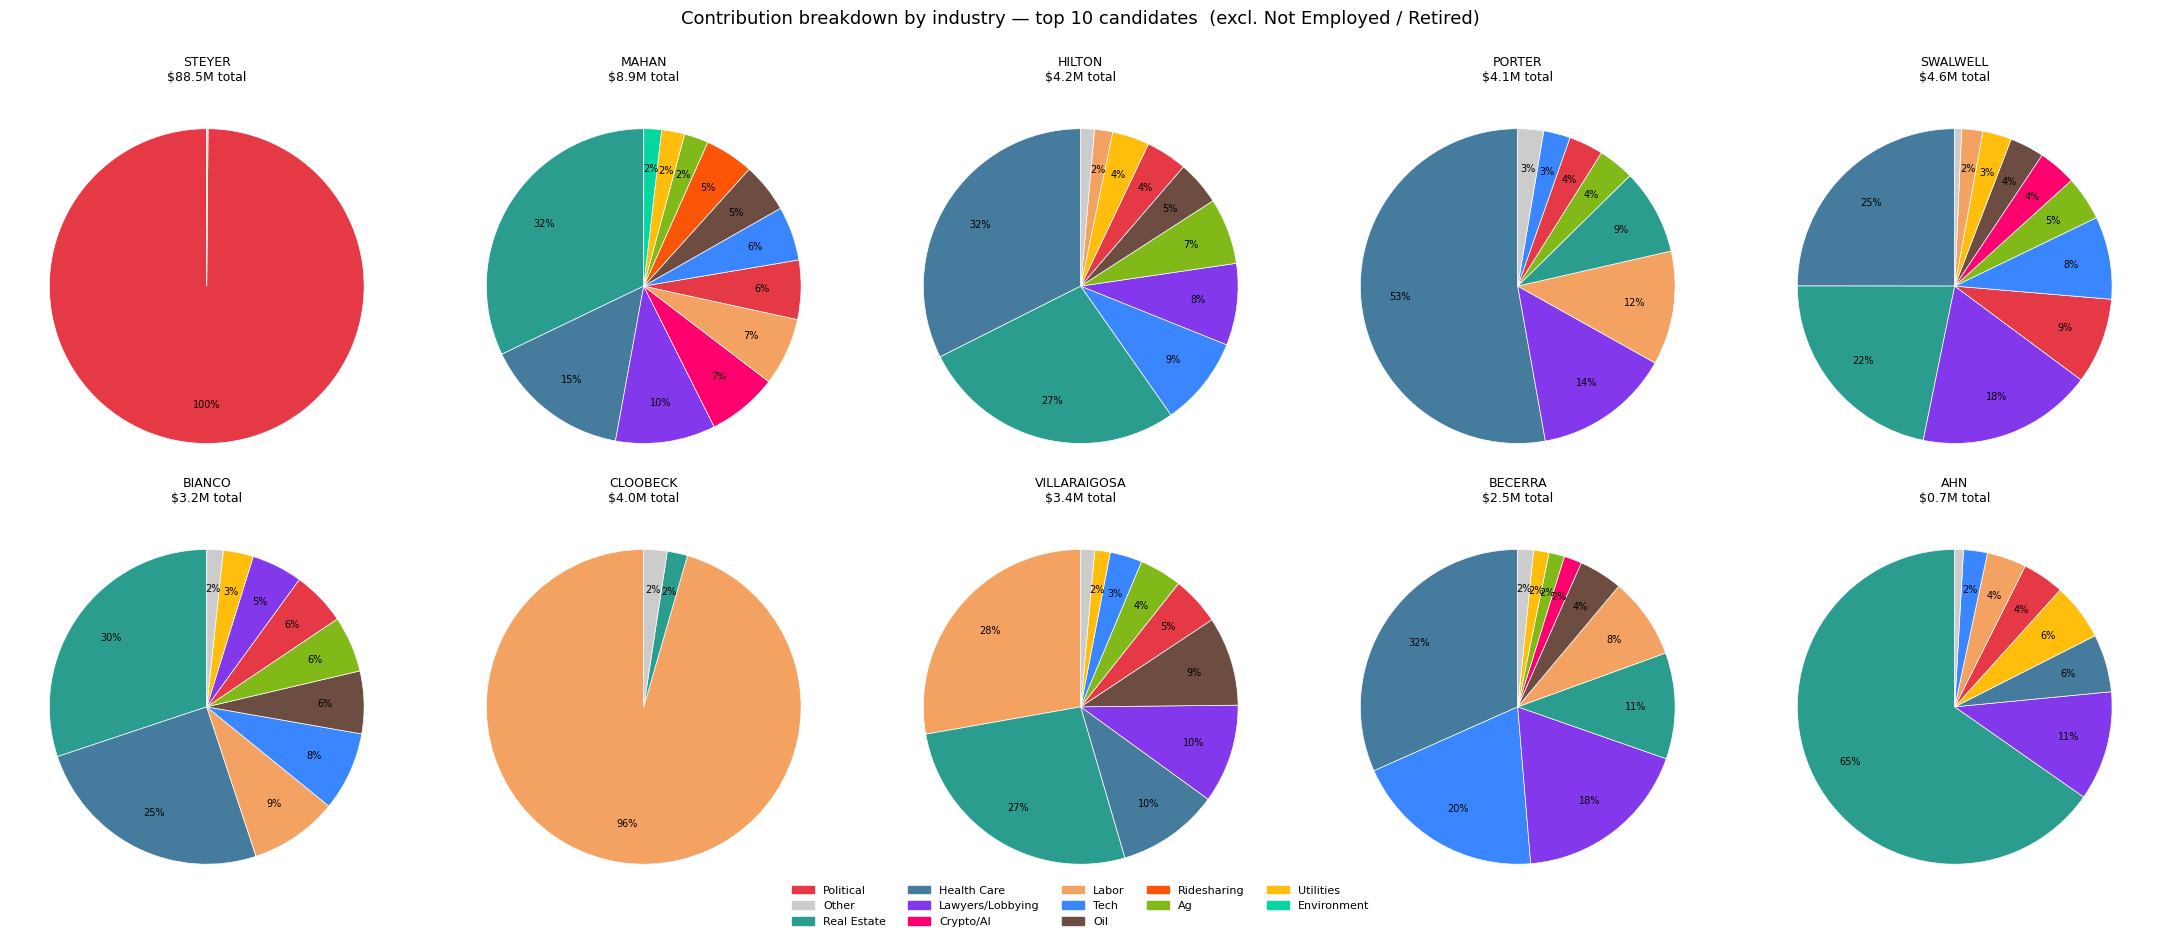

In [21]:
# Same charts excluding "Not Employed / Retired" to focus on organised-sector money
res_active = res[res["Industry_Category"] != "Not Employed / Retired"].copy()

fig2, axes2 = plt.subplots(nrows, ncols, figsize=(22, 9))
axes2_flat  = axes2.flatten()

legend_handles2 = {}
for ax, candidate in zip(axes2_flat, top10_candidates):
    cats, cols = pie_for_candidate(ax, candidate, res_active, CATEGORY_COLORS)
    for cat, col in zip(cats, cols):
        if cat not in legend_handles2:
            legend_handles2[cat] = col

for ax in axes2_flat[len(top10_candidates):]:
    ax.set_visible(False)

patches2 = [mpatches.Patch(color=col, label=cat)
            for cat, col in legend_handles2.items()]
fig2.legend(handles=patches2, loc="lower center", ncol=5,
            fontsize=8, frameon=False, bbox_to_anchor=(0.5, -0.02))
fig2.suptitle("Contribution breakdown by industry — top 10 candidates  "
              "(excl. Not Employed / Retired)",
              fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
